In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

In [86]:
import sys
sys.path.insert(0,'../st_validate')

SMALL_SIZE = 10
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

import os
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import pickle
import sta_validate # import functions for phantom creation and sta tests
import sta # import functions for computing structure tensors and angles
import periodic_kmeans # import functions for angle clustering in 2D
import utils
import visualize
from skimage.transform import resize
from skimage.color import rgb2gray

HOME = "/home/brysongray/structure_tensor_validation/"
g_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
w_sigmas = np.linspace(start=0.0, stop=5.0, num=10)
plt.ioff()

## Variable noise analysis

In [95]:
errors_path = "/home/bgray/bmap/fibermetric/st_validation/sta_2d_var_noise_out"
# errors_path = "/nafs/dtward/bryson/fibermetric/st_validation/sta_2d_out_7-25-24"

errors_files = os.listdir(errors_path)
all_dataframes = []

for file in errors_files:
    file_path = os.path.join(errors_path, file)
    df = pd.read_pickle(file_path)
    all_dataframes.append(df)

combined_dataframe = pd.concat(all_dataframes, ignore_index=True)

In [50]:
combined_dataframe.iloc[0]

derivative_sigma                                        0.15
tensor_sigma                                             0.0
AI                                                       1.0
period                                                  13.0
width                                                    1.0
angles              [0.3649324799624507, 1.5231964381041423]
noise                                               0.033333
error                                               5.107683
Name: 0, dtype: object

In [89]:
derivative_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
tensor_sigmas = np.linspace(start=0.0, stop=5.0, num=10)
print(derivative_sigmas)
print(tensor_sigmas)

[0.15       0.41111111 0.67222222 0.93333333 1.19444444 1.45555556
 1.71666667 1.97777778 2.23888889 2.5       ]
[0.         0.55555556 1.11111111 1.66666667 2.22222222 2.77777778
 3.33333333 3.88888889 4.44444444 5.        ]


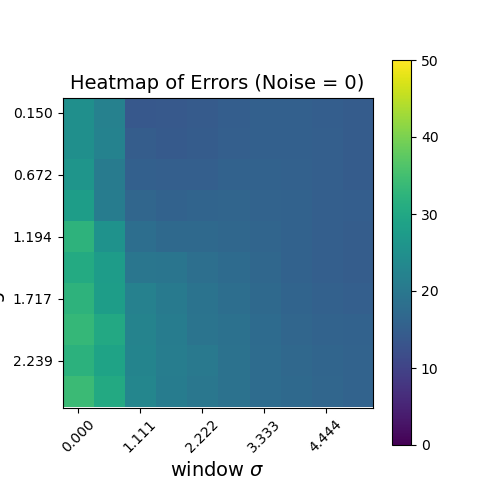

In [99]:
# Filter the dataframe for rows where noise is zero
# filtered_df = combined_dataframe[combined_dataframe['noise'] == 0]
filtered_df = combined_dataframe[(combined_dataframe['noise'] == 0) &
                                 (combined_dataframe["angles"].apply(lambda x: np.array(x).shape == (2,))) &
                                 (combined_dataframe['AI'] == 3.0)
                                 ]

# Group by derivative_sigma and tensor_sigma, and calculate the mean error
heatmap_data = filtered_df.groupby(['derivative_sigma', 'tensor_sigma'])['error'].median().unstack()

# Plot the heatmap
plt.figure(figsize=(5, 5))
xticklabels = [f"{x:.3f}" for x in tensor_sigmas]
yticklabels = [f"{x:.3f}" for x in derivative_sigmas]
plt.xticks(np.arange(len(xticklabels))[::2], labels=xticklabels[::2], rotation=45)
plt.yticks(np.arange(len(yticklabels))[::2], labels=yticklabels[::2])
plt.imshow(np.array(heatmap_data), vmin=0.0, vmax=50.0)
plt.title("Heatmap of Errors (Noise = 0)")
plt.xlabel(r"window $\sigma$")
plt.ylabel(r"gradient $\sigma$")
plt.colorbar()
plt.show()

In [100]:
print(f"min error: {np.array(heatmap_data).min()}\n"
      f"argmin: {np.array(heatmap_data).argmin()}")

min error: 13.727859414669938
argmin: 2


In [101]:
tensor_sigma_target = tensor_sigmas[2]
derivative_sigma_target = derivative_sigmas[1]
filtered_rows = combined_dataframe[
    (combined_dataframe["angles"].apply(lambda x: np.array(x).shape == (2,))) &
    (combined_dataframe['derivative_sigma'] == derivative_sigma_target) &
    (combined_dataframe['tensor_sigma'] == tensor_sigma_target) &
    (combined_dataframe['AI'] == 1.0)
]
AI_1 = filtered_rows.drop(columns=["derivative_sigma", "tensor_sigma", "AI", "period", "width", "angles"]).groupby(["noise"]).median()

In [102]:
tensor_sigma_target = tensor_sigmas[2]
derivative_sigma_target = derivative_sigmas[0]
filtered_rows = combined_dataframe[
    (combined_dataframe['derivative_sigma'] == derivative_sigma_target) & 
    (combined_dataframe['tensor_sigma'] == tensor_sigma_target) &
    (combined_dataframe['AI'] == 3.0)
]
AI_3 = filtered_rows.drop(columns=["derivative_sigma", "tensor_sigma", "AI", "period", "width", "angles"]).groupby(["noise"]).median()

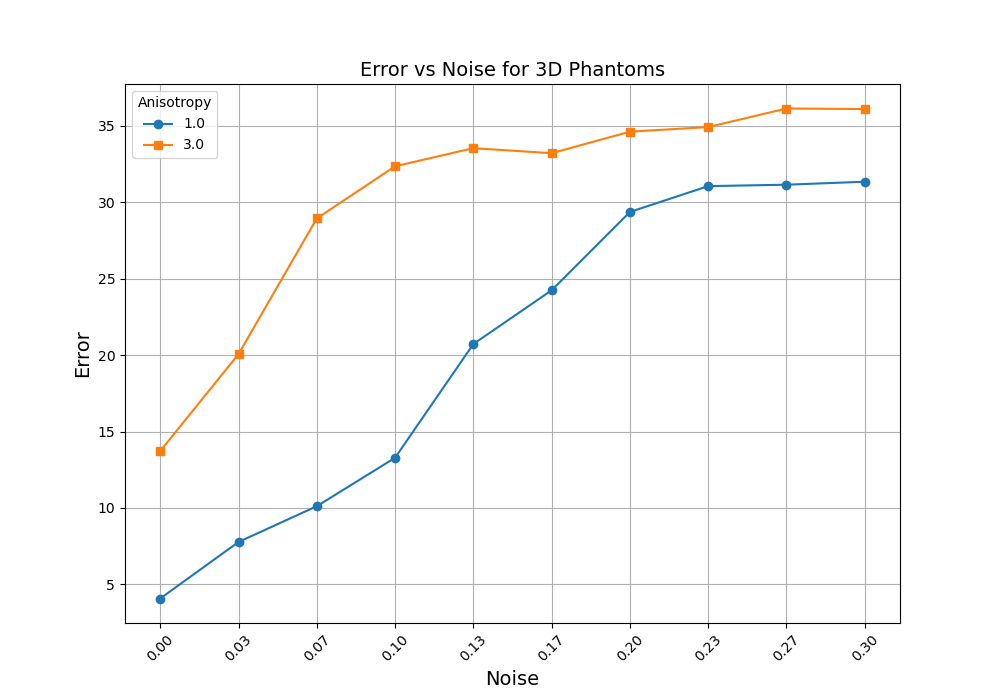

In [103]:
plt.figure(figsize=(10,7))
plt.plot(AI_1.index, AI_1['error'], label='1.0', marker='o')
plt.plot(AI_3.index, AI_3['error'], label='3.0', marker='s')
plt.xlabel('Noise')
plt.ylabel('Error')
plt.title('Error vs Noise for 3D Phantoms')
ticklabels = [f"{x:.2f}" for x in AI_1.index]
ticks = np.array(AI_1.index)
plt.xticks(ticks, labels=ticklabels, rotation=45)
legend = plt.legend()
legend.set_title("Anisotropy")
plt.grid(True)
plt.show()

## Error vs Anisotropic Dimension Component Analysis

In [73]:
errors_path = "/nafs/dtward/bryson/fibermetric/st_validation/sta_3d_out_7-25-24"
errors_files = os.listdir(errors_path)
all_dataframes = []

for file in errors_files:
    file_path = os.path.join(errors_path, file)
    df = pd.read_pickle(file_path)
    all_dataframes.append(df)

combined_dataframe = pd.concat(all_dataframes, ignore_index=True)

In [4]:
np.unique(combined_dataframe["AI"])

array([1.        , 2.        , 3.        , 4.        , 5.14285714,
       6.        , 7.2       , 8.        ])

In [74]:
filtered_rows = combined_dataframe[combined_dataframe["angles"].apply(lambda x: np.array(x).shape == (2,))]
# filtered_rows_AI_2 = filtered_rows[filtered_rows["AI"]==2.0]
# filtered_rows_AI_3 = filtered_rows[filtered_rows["AI"]==3.0]
# filtered_rows_AI_4 = filtered_rows[filtered_rows["AI"]==4.0]
# filtered_rows_AI_5 = filtered_rows[filtered_rows["AI"]==np.unique(combined_dataframe["AI"])[4]]
# filtered_rows_AI_6 = filtered_rows[filtered_rows["AI"]==6.0]
# filtered_rows_AI_7 = filtered_rows[filtered_rows["AI"]==7.2]
# filtered_rows_AI_8 = filtered_rows[filtered_rows["AI"]==8.0]

In [75]:
filtered_rows

,derivative_sigma,tensor_sigma,AI,period,width,angles,error
240000,0.15,0.000000,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",16.706709
240001,0.15,0.555556,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",0.268501
240002,0.15,1.111111,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",0.471223
240003,0.15,1.666667,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",0.582446
240004,0.15,2.222222,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",0.607158
...,...,...,...,...,...,...,...
479995,2.50,2.777778,8.0,13.0,1.0,"[2.3471598180330293, 0.3718074288765335]",1.712486
479996,2.50,3.333333,8.0,13.0,1.0,"[2.3471598180330293, 0.3718074288765335]",1.720728
479997,2.50,3.888889,8.0,13.0,1.0,"[2.3471598180330293, 0.3718074288765335]",1.695214
479998,2.50,4.444444,8.0,13.0,1.0,"[2.3471598180330293, 0.3718074288765335]",1.659331


In [77]:
filtered_rows

,derivative_sigma,tensor_sigma,AI,period,width,angles,error,angle_0,angle_1
240000,0.15,0.000000,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",16.706709,0.105012,1.349897
240001,0.15,0.555556,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",0.268501,0.105012,1.349897
240002,0.15,1.111111,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",0.471223,0.105012,1.349897
240003,0.15,1.666667,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",0.582446,0.105012,1.349897
240004,0.15,2.222222,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",0.607158,0.105012,1.349897
...,...,...,...,...,...,...,...,...,...
479995,2.50,2.777778,8.0,13.0,1.0,"[2.3471598180330293, 0.3718074288765335]",1.712486,2.347160,0.371807
479996,2.50,3.333333,8.0,13.0,1.0,"[2.3471598180330293, 0.3718074288765335]",1.720728,2.347160,0.371807
479997,2.50,3.888889,8.0,13.0,1.0,"[2.3471598180330293, 0.3718074288765335]",1.695214,2.347160,0.371807
479998,2.50,4.444444,8.0,13.0,1.0,"[2.3471598180330293, 0.3718074288765335]",1.659331,2.347160,0.371807


In [80]:
filtered_rows['angle_0'] = filtered_rows['angles'].apply(lambda x: x[0])
filtered_rows['angle_1'] = filtered_rows['angles'].apply(lambda x: x[1])
grouped_by_angle_0 = filtered_rows.drop(columns=["derivative_sigma", "tensor_sigma", "period", "width", "angles"]).groupby(['angle_0', 'AI'], as_index=False).median()
grouped_by_angle_1 = filtered_rows.drop(columns=["derivative_sigma", "tensor_sigma", "period", "width", "angles"]).groupby(['angle_1', 'AI'], as_index=False).median()


/tmp/ipykernel_3854620/603167408.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rows['angle_0'] = filtered_rows['angles'].apply(lambda x: x[0])
/tmp/ipykernel_3854620/603167408.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rows['angle_1'] = filtered_rows['angles'].apply(lambda x: x[1])


In [81]:
grouped_by_angle_0

,angle_0,AI,error,angle_1
0,0.105012,1.000000,0.388605,1.349897
1,0.105012,2.000000,0.348630,1.349897
2,0.105012,3.000000,0.320253,1.349897
3,0.105012,4.000000,0.304271,1.349897
4,0.105012,5.142857,0.301120,1.349897
...,...,...,...,...
795,2.966959,4.000000,0.373831,2.384144
796,2.966959,5.142857,0.350766,2.384144
797,2.966959,6.000000,0.344952,2.384144
798,2.966959,7.200000,0.340258,2.384144


In [ ]:
np.unique(combined_dataframe["AI"])[1::2]

array([2., 4., 6., 8.])

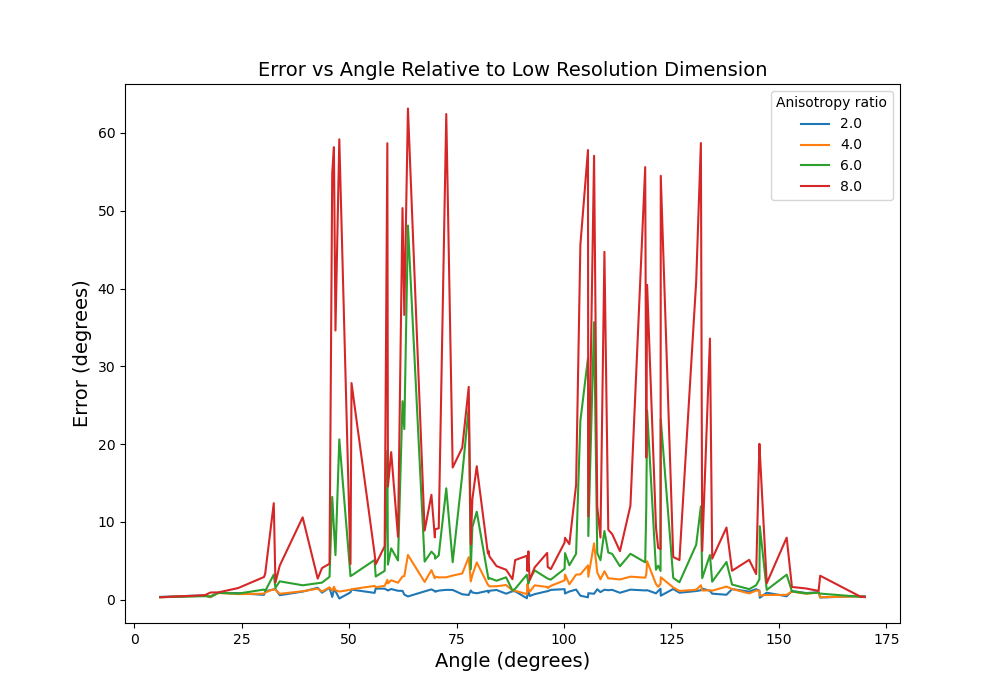

In [87]:
# plot error vs angle_0
angle = grouped_by_angle_0["angle_0"].unique() * 180/np.pi

plt.figure(figsize=(10,7))
for n in np.unique(combined_dataframe["AI"])[1::2]:
    error = grouped_by_angle_0[grouped_by_angle_0["AI"]==n]["error"]
    plt.plot(angle, error, label=f"{n}")
    
plt.title("Error vs Angle Relative to Low Resolution Dimension")
plt.ylabel("Error (degrees)")
plt.xlabel("Angle (degrees)")
legend = plt.legend()
legend.set_title("Anisotropy ratio")
plt.show()

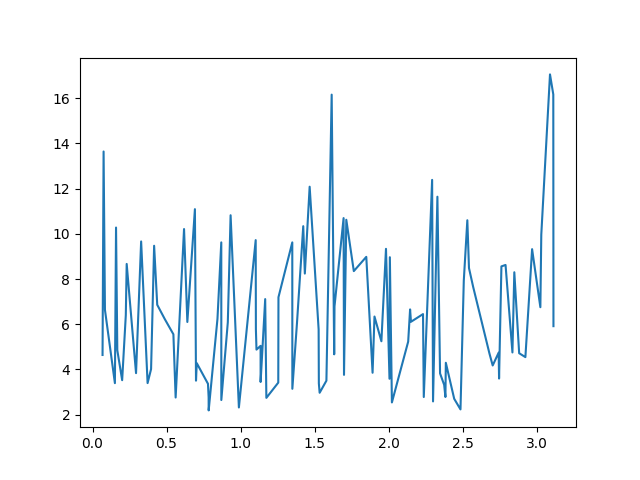

In [59]:
# plot error vs angle_1
angle = grouped_by_angle_1.index
error = grouped_by_angle_1["mean_err"]

plt.figure()
plt.plot(angle, error)
plt.show()

In [21]:
angles = np.stack(filtered_rows["angles"])
theta = angles[:,0]
phi = angles[:,1]
errors = np.array(filtered_rows["mean_err"])

In [25]:
np.unique(theta, return_counts=True)

(array([0.10501248, 0.2855414 , 0.30909004, 0.34109466, 0.42213962,
        0.52681012, 0.53148245, 0.56626805, 0.57294834, 0.5905425 ,
        0.68351658, 0.74472993, 0.76215472, 0.79270801, 0.80373806,
        0.8105568 , 0.81687111, 0.83244322, 0.87785638, 0.88206161,
        0.97568944, 0.98036845, 1.01669658, 1.02759841, 1.02993651,
        1.0431882 , 1.07090432, 1.08917019, 1.09650466, 1.11126442,
        1.17905937, 1.20666466, 1.22059478, 1.22155858, 1.23634147,
        1.26694186, 1.2929691 , 1.33185765, 1.35819958, 1.36653447,
        1.37295951, 1.39072774, 1.43610942, 1.43854648, 1.44213646,
        1.47115575, 1.51001204, 1.53572806, 1.54688415, 1.59434319,
        1.59667101, 1.60073075, 1.60538347, 1.62600545, 1.6767581 ,
        1.67908146, 1.69151145, 1.74757812, 1.74939319, 1.76696101,
        1.7943213 , 1.81171368, 1.84256195, 1.84396009, 1.86732621,
        1.88021893, 1.89323264, 1.90939246, 1.92502945, 1.94093602,
        1.97249986, 2.01498017, 2.07504785, 2.07

In [ ]:
plt.figure()
plt.plot()

array([25.30252775, 11.34639293,  3.00916771, ...,  7.86979116,
        7.98359389,  8.06878195], shape=(240000,))